# S2 | Abstention Analysis

Classifies model outputs under **blind** and **inst_blind** conditions into:
- `hard_abstained` — explicit refusal ("I cannot see")
- `soft_abstained` — implicit abstention ("nothing", "unknown")
- `hallucinated_correct` — committed answer, happens to be right
- `hallucinated_wrong` — committed wrong answer
- `degenerate` — empty / malformed output

Covers: per-model rates, soft-abstention collapse, confidence profiles,
op/entity breakdowns, answer biases, blind→inst transitions.

In [73]:
import json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
from matplotlib.patches import Patch
from pathlib import Path
import sys

BASE = Path('/home/david/Desktop/yuna/HPA')
sys.path.insert(0, str(BASE / 'analysis'))

from utils.constants import (
    CLASS_COLOR,
    CLASS_ORDER,
    COND_LABEL,
    VARIANT_ORDER,
    VARIANT_LABELS,
    VARIANT_COLORS,
)
from utils.vqa import VQAAnswerMapper, vqa_accuracy
from utils.load_session import MODEL_TYPE, _default_all_models, clean_answer

SEMANTICS_PATH = BASE / 'dataset/vqa/vqa1k_semantics.jsonl'

mapper = VQAAnswerMapper()
ALL_MODELS = _default_all_models(BASE)
MODEL_DIRS = {label: results_dir / model_dir for label, (results_dir, model_dir) in ALL_MODELS.items()}
MODEL_ORDER = [label for label in MODEL_TYPE if label in MODEL_DIRS]

qid_meta = (
    pd.read_json(SEMANTICS_PATH, lines=True)[['question_id', 'ent', 'op']]
    .drop_duplicates('question_id')
    .set_index('question_id')
    .to_dict('index')
)


In [74]:
hard_re = re.compile(
    r'cannot|can\'t|don\'t see|no image|unable|not visible'
    r'|i cannot|i don\'t|can not|no visual|cannot see'
    r'|i\'m not able|i am not able|\bblank\b',
    re.I
)
SOFT_WORDS = {
    'nothing', 'unanswerable', 'unclear', 'unknown', 'nowhere',
    'n/a', 'na', 'indeterminate', 'unidentifiable', 'no sign',
    "can't tell", 'cannot tell', 'not clear', 'not visible',
}

def classify(output, gt_answers):
    if not output or not output.strip():
        return 'degenerate'
    out_lower = output.strip().lower().strip('.,!? ')
    if hard_re.search(output):
        return 'hard_abstained'
    if out_lower in SOFT_WORDS:
        return 'soft_abstained'
    if out_lower in {'answer', 'a', 'the'}:
        return 'degenerate'
    if gt_answers and vqa_accuracy(output, gt_answers) > 0:
        return 'hallucinated_correct'
    return 'hallucinated_wrong'

# Sanity check
tests = [
    ('nothing',   [],             'soft_abstained'),
    ('I cannot see', [],          'hard_abstained'),
    ('tennis',    ['tennis'],     'hallucinated_correct'),
    ('blue',      ['red'],        'hallucinated_wrong'),
    ('',          [],             'degenerate'),
    ('blanket',   [],             'hallucinated_wrong'),
]
for out, gt, expected in tests:
    got = classify(out, gt)
    status = 'OK' if got == expected else f'FAIL got {got}'
    print(f'  {status:20s}  classify({out!r}) = {got}')

  OK                    classify('nothing') = soft_abstained
  OK                    classify('I cannot see') = hard_abstained
  OK                    classify('tennis') = hallucinated_correct
  OK                    classify('blue') = hallucinated_wrong
  OK                    classify('') = degenerate
  OK                    classify('blanket') = hallucinated_wrong


In [ ]:
# ── Load blind / inst_blind JSONL records for all models ─────────────────────
CT_FOCUS = 'question'   # analyse the canonical variant for abstention

records = []
for model in MODEL_ORDER:
    model_dir = MODEL_DIRS[model]
    for cond in ['blind', 'inst_blind']:
        path = model_dir / f'vqa_1k_control_{cond}.jsonl'
        if not path.exists():
            print(f'  MISSING: {path}')
            continue
        n_loaded = n_skip = 0
        for line in open(path):
            rec = json.loads(line)
            qid = int(rec['question_id'])
            ga  = rec.get('generated_answers') or {}
            gl  = rec.get('generated_logits') or {}
            if CT_FOCUS not in ga:
                n_skip += 1
                continue
            output  = clean_answer(ga[CT_FOCUS] or '')
            gt      = mapper.get_answers(qid)
            lp      = gl.get(CT_FOCUS, {})
            tokens  = lp.get('content', []) if isinstance(lp, dict) else []
            n_tokens = len(tokens)
            logprob = sum(t['logprob'] for t in tokens) if tokens else float('nan')
            mean_logprob = (logprob / n_tokens) if n_tokens else float('nan')
            meta = qid_meta.get(qid, {})
            records.append({
                'model': model, 'condition': cond, 'question_id': qid,
                'output': output, 'gt': gt, 'logprob': logprob, 'mean_logprob': mean_logprob, 'n_tokens': n_tokens,
                'ent': meta.get('ent', 'other'), 'op': meta.get('op', 'other'),
            })
            n_loaded += 1
        skip_str = f' (skipped {n_skip})' if n_skip else ''
        print(f'  {model:35s}  {cond:12s}  n={n_loaded}{skip_str}')

df = pd.DataFrame(records)
df['class'] = df.apply(lambda r: classify(r['output'], r['gt']), axis=1)
print()
print(f'Total rows: {len(df)}')
print(f'Models: {df["model"].nunique()}  |  Conditions: {list(df["condition"].unique())}')


   Loading VQA annotations from /home/david/Desktop/yuna/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations
  Qwen3-VL-8B                          blind         n=1000
  Qwen3-VL-8B                          inst_blind    n=994 (skipped 6)
  LLaVA-1.5-7B                         blind         n=1000
  LLaVA-1.5-7B                         inst_blind    n=1000
  LLaVA-Mistral                        blind         n=1000
  LLaVA-Mistral                        inst_blind    n=1000
  LLaVA-Vicuna                         blind         n=1000
  LLaVA-Vicuna                         inst_blind    n=1000
  InternVL-1B                          blind         n=1000
  InternVL-1B                          inst_blind    n=1000
  InternVL-2B                          blind         n=1000
  InternVL-2B                          inst_blind    n=1000
  InternVL-8B                          blind         n=1000
  InternVL-8B                          inst_blind    n=1000
  LLaVA-1.5 (L

## 2. Per-Model Abstention Rates

Key expectations:
- Hard abstention near 0% — baked-in 'Answer using a single word or phrase' suppresses explicit refusals
- Soft abstention (11-19%) is the real signal
- Under inst_blind, soft abstentions largely collapse to hallucinations

Model                               Cond             n |  hard%  soft%  hal+%  hal-% degen%
------------------------------------------------------------------------------------------
Qwen3-VL-8B                         blind         1000 |    0.1    8.7   37.8   53.4    0.0
Qwen3-VL-8B                         inst_blind     994 |    0.7    2.5   41.0   55.6    0.1
LLaVA-1.5-7B                        blind         1000 |    0.1   11.7   36.7   51.4    0.1
LLaVA-1.5-7B                        inst_blind    1000 |    0.1   10.6   36.5   52.8    0.0
LLaVA-Mistral                       blind         1000 |    0.1   11.4   37.9   50.6    0.0
LLaVA-Mistral                       inst_blind    1000 |    0.4    5.9   40.1   53.6    0.0
LLaVA-Vicuna                        blind         1000 |    0.0    7.9   38.3   53.7    0.1
LLaVA-Vicuna                        inst_blind    1000 |    0.0    7.1   37.5   55.4    0.0
InternVL-1B                         blind         1000 |    0.1    0.1   40.2   5

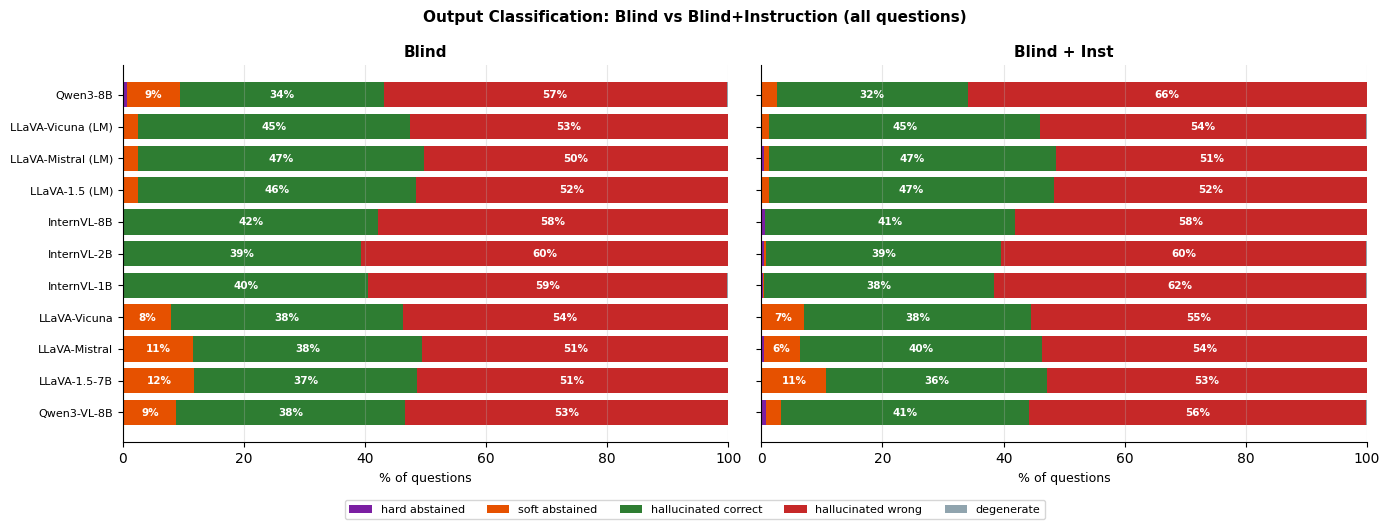

In [ ]:
rate_rows = []
for model in MODEL_ORDER:
    for cond in ['blind', 'inst_blind']:
        sub = df[(df['model'] == model) & (df['condition'] == cond)]
        if len(sub) == 0:
            continue
        counts = sub['class'].value_counts()
        row = {'model': model, 'condition': cond, 'n': len(sub)}
        for cls in CLASS_ORDER:
            row[cls] = counts.get(cls, 0) / len(sub) * 100
        rate_rows.append(row)

rate_df = pd.DataFrame(rate_rows)
print(f'{"Model":35s} {"Cond":12s} {"n":>5s} | '
      f'{"hard%":>6s} {"soft%":>6s} {"hal+%":>6s} {"hal-%":>6s} {"degen%":>6s}')
print('-' * 90)
for _, r in rate_df.iterrows():
    print(f'{r["model"]:35s} {r["condition"]:12s} {int(r["n"]):>5d} | '
          f'{r["hard_abstained"]:>6.1f} {r["soft_abstained"]:>6.1f} '
          f'{r["hallucinated_correct"]:>6.1f} {r["hallucinated_wrong"]:>6.1f} '
          f'{r["degenerate"]:>6.1f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, cond in zip(axes, ['blind', 'inst_blind']):
    sub = rate_df[rate_df['condition'] == cond].set_index('model').reindex(MODEL_ORDER)
    bottom = np.zeros(len(sub))
    for cls in CLASS_ORDER:
        vals = sub[cls].fillna(0).values
        ax.barh(range(len(sub)), vals, left=bottom,
                color=CLASS_COLOR[cls], label=cls.replace('_', ' '))
        for i, (v, b) in enumerate(zip(vals, bottom)):
            if v > 3:
                ax.text(b + v/2, i, f'{v:.0f}%', ha='center', va='center',
                        fontsize=7.5, color='white', fontweight='bold')
        bottom += vals
    ax.set_yticks(range(len(MODEL_ORDER)))
    ax.set_yticklabels(MODEL_ORDER, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel('% of questions', fontsize=9)
    ax.set_title(COND_LABEL[cond], fontsize=11, fontweight='bold')
    ax.set_xlim(0, 100)
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=8,
           bbox_to_anchor=(0.5, -0.05))
fig.suptitle('Output Classification: Blind vs Blind+Instruction (all questions)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Soft Abstention Collapse: blind → inst

For each question where the model soft-abstained under blind, does inst make it commit?
The **collapse rate** = fraction of blind soft-abstentions that become a committed answer under inst.

- High collapse (Qwen3) = model has the prior but suppresses it without permission
- Low collapse (LLaVA-1.5) = always-on hallucination, instruction barely registers

Model                               soft_blind%  collapse% ans_change%
----------------------------------------------------------------------
Qwen3-VL-8B                                8.6       72.1        33.0
LLaVA-1.5-7B                              11.7       12.8        11.9
LLaVA-Mistral                             11.4       49.1        20.1
LLaVA-Vicuna                               7.9       22.8        16.0
InternVL-1B                                0.1      100.0        28.6
InternVL-2B                                0.0        0.0        28.3
InternVL-8B                                0.0        0.0        42.1
LLaVA-1.5 (LM)                             2.4       50.0        20.0
LLaVA-Mistral (LM)                         2.2       54.5        20.9
LLaVA-Vicuna (LM)                          2.3       43.5        20.0
Qwen3-8B                                   8.7       75.9        45.8


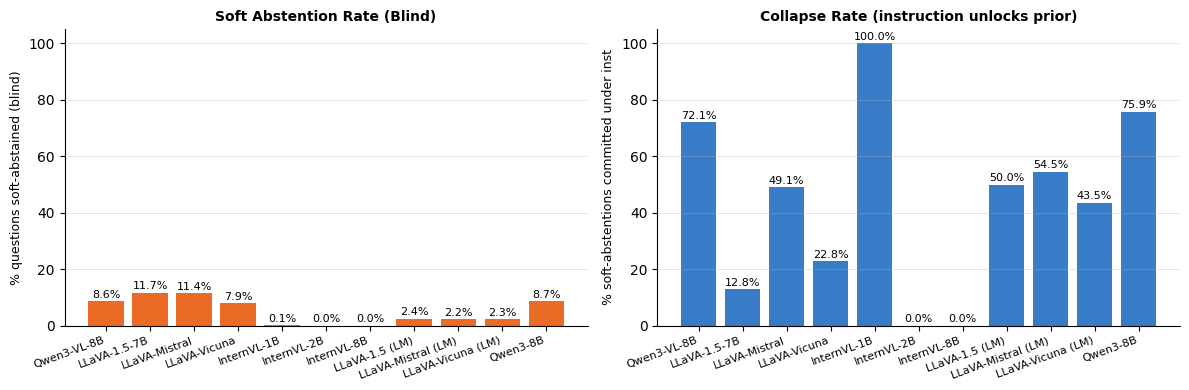


Examples: soft-abstained blind -> committed inst:

  Qwen3-VL-8B:
    QID 397117003  blind='unanswerable'  inst='based on most common or universal scenario for truck cargo is typically goods or freight however since question asks for single word or phrase and goods is very common and appropriate term for what truck carries: goods'  GT=[cement, cement, concrete]
    QID 397303000  blind='nowhere'  inst='not possible'  GT=[outside, ground, alongside tables]
    QID 135486006  blind='nothing'  inst='bag'  GT=[kite, kite, kite]
    QID 399462000  blind='nothing'  inst='dancing'  GT=[running, running, running]

  LLaVA-1.5-7B:
    QID 397117003  blind='nothing'  inst='no cargo'  GT=[cement, cement, concrete]
    QID 399462000  blind='nothing'  inst='no action'  GT=[running, running, running]
    QID 417164002  blind='nothing'  inst='no red and white sign'  GT=[open 24 hours, open 24 hours, open 24 hours]
    QID 155341004  blind='nothing'  inst='no red object'  GT=[car, car, truck]

  LLaV

In [ ]:
collapse_rows = []
for model in MODEL_ORDER:
    b = df[(df['model'] == model) & (df['condition'] == 'blind')]
    i = df[(df['model'] == model) & (df['condition'] == 'inst_blind')]
    if len(b) == 0 or len(i) == 0:
        continue
    merged = b[['question_id', 'class', 'output']].merge(
        i[['question_id', 'class', 'output']].rename(
            columns={'class': 'class_i', 'output': 'output_i'}), on='question_id')
    soft_b   = merged[merged['class'] == 'soft_abstained']
    n_soft   = len(soft_b)
    committed = soft_b[soft_b['class_i'].isin(['hallucinated_correct', 'hallucinated_wrong'])]
    n_collapsed = len(committed)
    change_pct = (merged['output'].str.lower().str.strip() !=
                  merged['output_i'].str.lower().str.strip()).mean() * 100
    collapse_rows.append({
        'model':           model,
        'n_questions':     len(merged),
        'n_soft_blind':    n_soft,
        'soft_blind_pct':  n_soft / len(b) * 100 if len(b) > 0 else 0,
        'collapse_rate':   n_collapsed / n_soft * 100 if n_soft > 0 else 0,
        'answer_change_pct': change_pct,
    })

coll_df = pd.DataFrame(collapse_rows)
print(f'{"Model":35s} {"soft_blind%":>10s} {"collapse%":>10s} {"ans_change%":>11s}')
print('-' * 70)
for _, r in coll_df.iterrows():
    print(f'{r["model"]:35s} {r["soft_blind_pct"]:>10.1f} '
          f'{r["collapse_rate"]:>10.1f} {r["answer_change_pct"]:>11.1f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(coll_df))
for ax, col, color, ylabel, title in [
    (axes[0], 'soft_blind_pct', '#e65100',
     '% questions soft-abstained (blind)', 'Soft Abstention Rate (Blind)'),
    (axes[1], 'collapse_rate',  '#1565c0',
     '% soft-abstentions committed under inst', 'Collapse Rate (instruction unlocks prior)'),
]:
    ax.bar(x, coll_df[col], color=color, alpha=0.85)
    for i, v in enumerate(coll_df[col]):
        ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(coll_df['model'], rotation=20, ha='right', fontsize=8)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylim(0, 105)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# Show examples
print('\nExamples: soft-abstained blind -> committed inst:')
for model in MODEL_ORDER[:3]:
    b = df[(df['model'] == model) & (df['condition'] == 'blind')]
    i = df[(df['model'] == model) & (df['condition'] == 'inst_blind')]
    merged = b[['question_id','class','output','gt']].merge(
        i[['question_id','class','output']].rename(
            columns={'class':'class_i','output':'output_i'}), on='question_id')
    ex = merged[(merged['class'] == 'soft_abstained') &
                (merged['class_i'].isin(['hallucinated_correct','hallucinated_wrong']))]
    if len(ex) == 0:
        continue
    print(f'\n  {model}:')
    for _, r in ex.head(4).iterrows():
        gt_str = ', '.join((r['gt'] or [])[:3])
        print(f'    QID {r["question_id"]}  blind={r["output"]!r}  '
              f'inst={r["output_i"]!r}  GT=[{gt_str}]')

## 4. Confidence Profile by Class

Log-probability sum per output, split by taxonomy class.
- Abstentions should be less confident (lower LP) than committed hallucinations
- inst_blind should raise confidence uniformly (permission = more committed hallucination)

In [ ]:
fig, axes = plt.subplots(2, len(MODEL_ORDER), figsize=(22, 8), sharey='row')

all_vals = df['mean_logprob'].dropna()
if len(all_vals):
    x_min = float(all_vals.quantile(0.01))
    x_max = float(all_vals.quantile(0.99))
else:
    x_min, x_max = -5.0, 0.0
shared_bins = np.linspace(x_min, x_max, 18)
plot_order = ['hallucinated_wrong', 'hallucinated_correct', 'soft_abstained', 'hard_abstained', 'degenerate']

for col, model in enumerate(MODEL_ORDER):
    for row_idx, cond in enumerate(['blind', 'inst_blind']):
        ax = axes[row_idx, col]
        sub = df[(df['model'] == model) & (df['condition'] == cond)]
        for cls in plot_order:
            vals = sub[sub['class'] == cls]['mean_logprob'].dropna()
            if len(vals) > 2:
                ax.hist(
                    vals,
                    bins=shared_bins,
                    weights=np.ones(len(vals)) * (100.0 / len(vals)),
                    histtype='step',
                    linewidth=1.7,
                    color=CLASS_COLOR[cls],
                    label=cls.replace('_', ' '),
                )
        ax.axvline(sub['mean_logprob'].median(), color='black', lw=1, ls='--', alpha=0.5)
        if row_idx == 0:
            ax.set_title(model[:20], fontsize=7.5, fontweight='bold')
        if col == 0:
            ax.set_ylabel(COND_LABEL[cond] + '\nDensity', fontsize=8)
        ax.set_xlabel('Mean token log-prob', fontsize=7)
        ax.set_ylim(0, 100)
        ax.spines[['top', 'right']].set_visible(False)

from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], color=CLASS_COLOR[c], lw=2, label=c.replace('_', ' '))
    for c in CLASS_ORDER
]
fig.legend(handles=handles, loc='lower center', ncol=5, fontsize=8,
           bbox_to_anchor=(0.5, -0.04))
fig.suptitle('Mean Token Log-Probability by Output Class (y-axis = % of questions; closer to 0 = more confident)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nMean token log-prob by class x condition (all models pooled):')
agg = df.groupby(['condition', 'class'])['mean_logprob'].agg(['mean', 'median', 'count'])
print(agg.round(3).to_string())

print('\nMean generated length by class x condition (all models pooled):')
len_agg = df.groupby(['condition', 'class'])['n_tokens'].agg(['mean', 'median', 'count'])
print(len_agg.round(2).to_string())


## 5. Op-Type Breakdown

Which cognitive operations lead to abstention vs hallucination under blind?

Expected:
- `text` (reading signs) -> high soft abstention — genuinely visually grounded
- `exist` / `count` -> default priors ('no', '0') rather than abstention
- `attr` (color) -> confident hallucination ('black') even without seeing

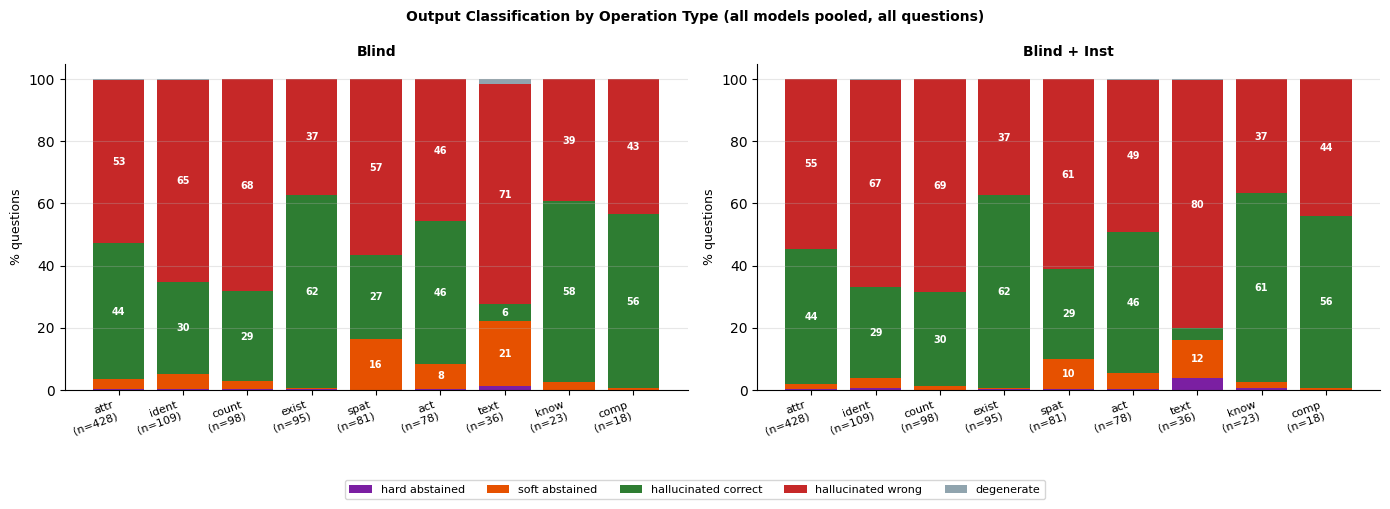


Soft abstention rate by op (blind, ranked):
op
text     21.0%
spat     16.4%
act       8.0%
temp      6.4%
ident     4.8%
attr      3.2%
count     2.6%
know      2.4%
cause     0.6%
comp      0.5%
exist     0.4%
other     0.0%


In [ ]:
def breakdown_plot(groupby_col, title, figname, top_n=None):
    groups = df[df['condition'] == 'blind'][groupby_col].value_counts()
    if top_n:
        groups = groups.head(top_n)
    group_names = groups.index.tolist()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    for ax, cond in zip(axes, ['blind', 'inst_blind']):
        sub = df[df['condition'] == cond]
        mat = []
        for g in group_names:
            grp = sub[sub[groupby_col] == g]
            if len(grp) == 0:
                mat.append([0] * len(CLASS_ORDER))
            else:
                mat.append([grp['class'].eq(c).mean() * 100 for c in CLASS_ORDER])
        mat = np.array(mat)
        bottom = np.zeros(len(group_names))
        for j, cls in enumerate(CLASS_ORDER):
            ax.bar(range(len(group_names)), mat[:, j], bottom=bottom,
                   color=CLASS_COLOR[cls], label=cls.replace('_', ' '))
            for i, (v, b) in enumerate(zip(mat[:, j], bottom)):
                if v > 5:
                    ax.text(i, b + v/2, f'{v:.0f}', ha='center', va='center',
                            fontsize=7, color='white', fontweight='bold')
            bottom += mat[:, j]
        n_per_group = df[df['question_id'] != -1].groupby(groupby_col)['question_id'].nunique()
        ax.set_xticks(range(len(group_names)))
        ax.set_xticklabels(
            [f'{g}\n(n={n_per_group.get(g, 0)})' for g in group_names],
            fontsize=8, rotation=20, ha='right')
        ax.set_ylabel('% questions', fontsize=9)
        ax.set_title(COND_LABEL[cond], fontsize=10, fontweight='bold')
        ax.set_ylim(0, 105)
        ax.grid(axis='y', alpha=0.3)
        ax.spines[['top', 'right']].set_visible(False)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=8,
               bbox_to_anchor=(0.5, -0.12))
    fig.suptitle(f'{title} (all models pooled, all questions)',
                 fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f'\nSoft abstention rate by {groupby_col} (blind, ranked):')
    blind_sub = df[df['condition'] == 'blind']
    soft_rates = blind_sub.groupby(groupby_col).apply(
        lambda g: (g['class'] == 'soft_abstained').mean() * 100
    ).sort_values(ascending=False)
    print(soft_rates.map(lambda v: f'{v:.1f}%').to_string())

breakdown_plot('op', 'Output Classification by Operation Type', 'abstention_by_op', top_n=9)

## 6. Entity-Type Breakdown

Expected:
- `text` entities (signs, labels) -> high soft abstention — requires visual OCR, cannot be guessed
- `person` -> medium abstention, but strong priors on actions/attributes
- `object` / `food` -> prior-driven hallucination (common object attributes well-memorised)
- `place` -> spatial priors weaker, higher abstention

In [ ]:
df.condition.unique()

<ArrowStringArray>
['blind', 'inst_blind']
Length: 2, dtype: str

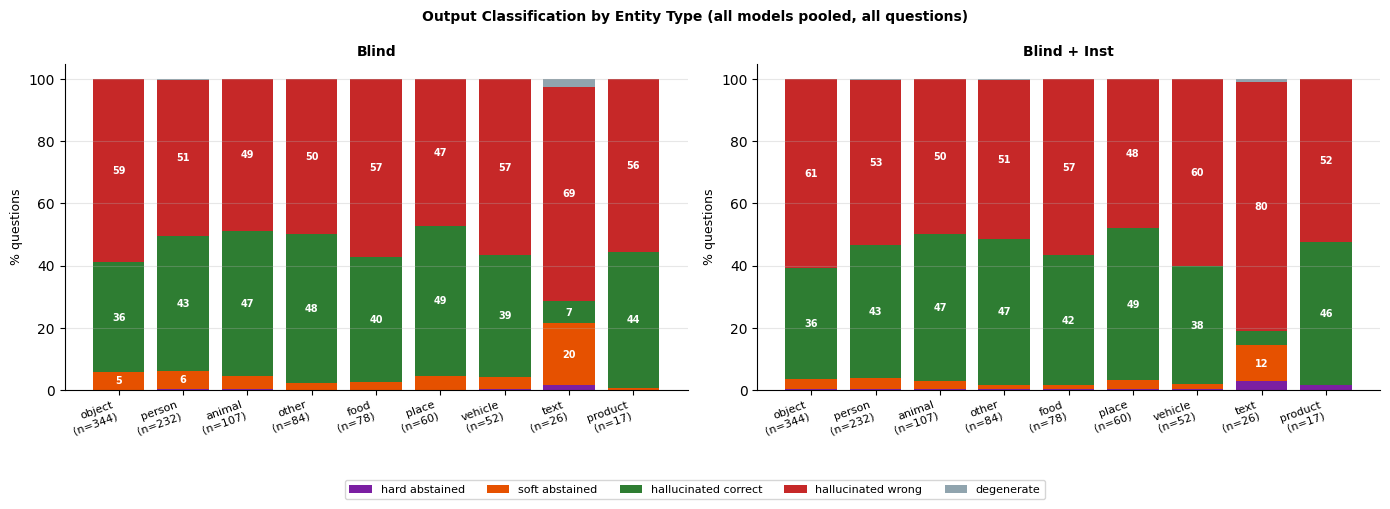


Soft abstention rate by ent (blind, ranked):
ent
text       19.9%
person      5.7%
object      5.5%
animal      4.2%
place       4.2%
vehicle     4.0%
food        2.6%
other       2.1%
product     0.5%


In [ ]:
breakdown_plot('ent', 'Output Classification by Entity Type', 'abstention_by_ent')

# Heatmap: soft abstention rate per op x ent
blind_sub = df[df['condition'] == 'inst_blind']
top_ops   = blind_sub['op'].value_counts().head(8).index.tolist()
top_ents  = blind_sub['ent'].value_counts().head(6).index.tolist()
heat_data = blind_sub[blind_sub['op'].isin(top_ops) & blind_sub['ent'].isin(top_ents)]
pivot = heat_data.groupby(['op', 'ent']).apply(
    lambda g: (g['class'] == 'soft_abstained').mean() * 100
).unstack('ent').reindex(top_ops)[top_ents]

## 7. Answer Distribution & Default Biases

Top-k output frequencies under blind and inst_blind reveal corpus-prior fingerprints:
- 'no' bias: yes/no questions -> models default to negation under uncertainty
- '0' bias: count questions -> null answer is zero, not 'unknown'
- 'black' dominance: color questions -> modal training color

Under inst_blind, content-specific answers emerge ('red', 'cat', 'grass') — activated priors.

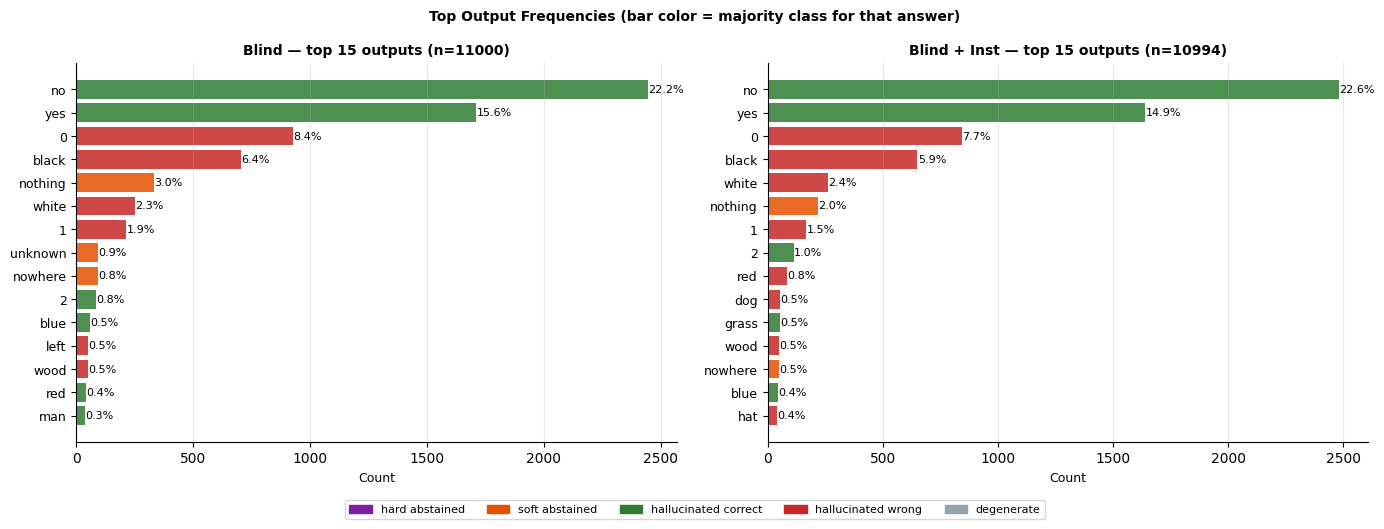

=== Yes/No bias (blind) ===
output
no     58.8%
yes    41.2%
Name: proportion, dtype: str

=== Yes/No bias (inst_blind) ===
output
no     60.2%
yes    39.8%
Name: proportion, dtype: str

=== Count answers (blind) ===
  '0'         :  681 (63.2%)
  '1'         :  183 (17.0%)
  '2'         :   83 (7.7%)
  '3'         :   31 (2.9%)
  'unknown'   :   28 (2.6%)
  '4'         :   15 (1.4%)
  '10'        :   15 (1.4%)
  '5'         :    8 (0.7%)


In [ ]:
TOP_K = 15
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, cond in zip(axes, ['blind', 'inst_blind']):
    sub = df[df['condition'] == cond]
    counts = sub['output'].value_counts().head(TOP_K)
    colors = []
    for ans in counts.index:
        cls_counts = sub[sub['output'] == ans]['class'].value_counts()
        colors.append(CLASS_COLOR[cls_counts.index[0]] if len(cls_counts) else '#90a4ae')
    ax.barh(range(len(counts)), counts.values, color=colors, alpha=0.85)
    ax.set_yticks(range(len(counts)))
    ax.set_yticklabels(counts.index, fontsize=9)
    ax.invert_yaxis()
    for i, v in enumerate(counts.values):
        ax.text(v + 1, i, f'{v/len(sub)*100:.1f}%', va='center', fontsize=8)
    ax.set_xlabel('Count', fontsize=9)
    ax.set_title(f'{COND_LABEL[cond]} — top {TOP_K} outputs (n={len(sub)})',
                 fontsize=10, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

handles = [Patch(color=CLASS_COLOR[c], label=c.replace('_', ' ')) for c in CLASS_ORDER]
fig.legend(handles=handles, loc='lower center', ncol=5, fontsize=8,
           bbox_to_anchor=(0.5, -0.05))
fig.suptitle('Top Output Frequencies (bar color = majority class for that answer)',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

print('=== Yes/No bias (blind) ===')
yn = df[(df['condition'] == 'blind') & (df['output'].isin(['yes', 'no']))]
print(yn['output'].value_counts(normalize=True)
      .map(lambda v: f'{v*100:.1f}%'))

print('\n=== Yes/No bias (inst_blind) ===')
yn2 = df[(df['condition'] == 'inst_blind') & (df['output'].isin(['yes', 'no']))]
print(yn2['output'].value_counts(normalize=True)
      .map(lambda v: f'{v*100:.1f}%'))

print('\n=== Count answers (blind) ===')
cnt = df[(df['condition'] == 'blind') & (df['op'] == 'count')]
for v, c in cnt['output'].value_counts().head(8).items():
    print(f'  {v!r:12s}: {c:4d} ({c/len(cnt)*100:.1f}%)')

## 8. Blind -> Inst Transition Analysis

4-way cross-tab per question:

| blind \ inst | abstained | committed |
|---|---|---|
| **abstained** | stable abstain | collapse (prior unlocked by instruction) |
| **committed** | late abstain (rare) | stable hallucination |

The **abstained-blind -> committed-inst** group is the most important:
the model has the prior but suppresses it without permission.

Model                                abs->abs  abs->comm  comm->abs  comm->comm
--------------------------------------------------------------------------------
Qwen3-VL-8B                               2.4        6.3        0.8        90.4
LLaVA-1.5-7B                             10.3        1.5        0.4        87.8
LLaVA-Mistral                             5.9        5.6        0.4        88.1
LLaVA-Vicuna                              6.1        1.8        1.0        91.1
InternVL-1B                               0.1        0.1        0.3        99.5
InternVL-2B                               0.0        0.0        0.7        99.3
InternVL-8B                               0.0        0.0        0.6        99.4
LLaVA-1.5 (LM)                            1.2        1.3        0.0        97.5
LLaVA-Mistral (LM)                        1.1        1.3        0.1        97.5
LLaVA-Vicuna (LM)                         1.3        1.1        0.0        97.6
Qwen3-8B                               

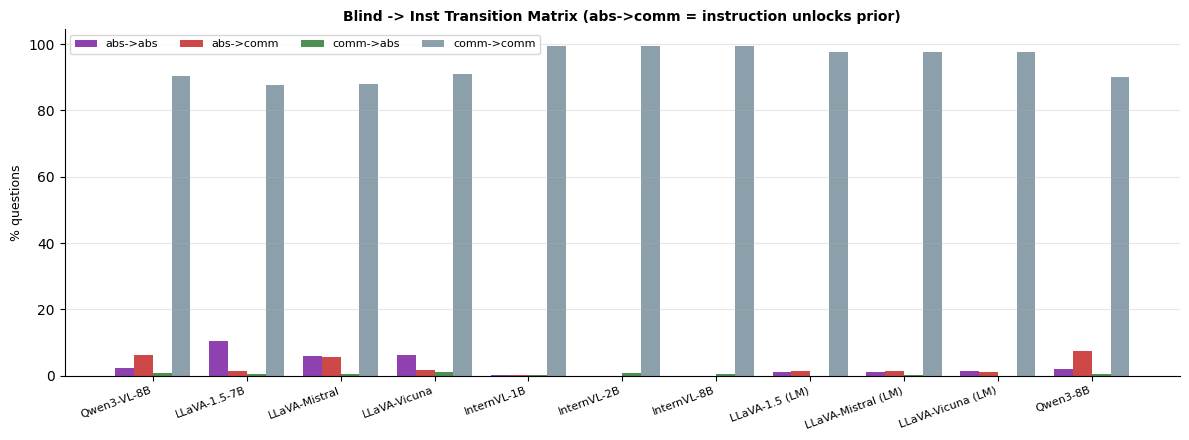


Canonical prior-exploitation examples (abs blind -> committed inst):

  Qwen3-VL-8B:
    [ident |object] blind='unanswerable'  inst='based on most common or universal scenario for truck cargo is typically goods or freight however since question asks for single word or phrase and goods is very common and appropriate term for what truck carries: goods'  GT=[cement, cement, concrete]
    [spat  |object] blind='nowhere'  inst='not possible'  GT=[outside, ground, alongside tables]
    [ident |person] blind='nothing'  inst='bag'  GT=[kite, kite, kite]
    [act   |person] blind='nothing'  inst='dancing'  GT=[running, running, running]
    [spat  |other ] blind='nowhere'  inst='fire'  GT=[building, train, train]

  LLaVA-1.5-7B:
    [ident |object] blind='nothing'  inst='no cargo'  GT=[cement, cement, concrete]
    [act   |person] blind='nothing'  inst='no action'  GT=[running, running, running]
    [text  |object] blind='nothing'  inst='no red and white sign'  GT=[open 24 hours, open 24 hour

In [ ]:
def is_abstained(cls):
    return cls in ('hard_abstained', 'soft_abstained')

trans_rows = []
for model in MODEL_ORDER:
    b = df[(df['model'] == model) & (df['condition'] == 'blind')]
    i = df[(df['model'] == model) & (df['condition'] == 'inst_blind')]
    if len(b) == 0 or len(i) == 0:
        continue
    merged = b[['question_id', 'class', 'output', 'ent', 'op']].merge(
        i[['question_id', 'class', 'output']].rename(
            columns={'class': 'class_i', 'output': 'output_i'}), on='question_id')
    n = len(merged)
    aa  = merged.apply(lambda r: is_abstained(r['class']) and     is_abstained(r['class_i']), axis=1).sum()
    ac  = merged.apply(lambda r: is_abstained(r['class']) and not is_abstained(r['class_i']), axis=1).sum()
    ca  = merged.apply(lambda r: not is_abstained(r['class']) and is_abstained(r['class_i']), axis=1).sum()
    cc  = merged.apply(lambda r: not is_abstained(r['class']) and not is_abstained(r['class_i']), axis=1).sum()
    trans_rows.append({'model': model, 'n': n,
                       'abs->abs': aa/n*100, 'abs->comm': ac/n*100,
                       'comm->abs': ca/n*100, 'comm->comm': cc/n*100})

trans_df = pd.DataFrame(trans_rows)
print(f'{"Model":35s} {"abs->abs":>9s} {"abs->comm":>10s} {"comm->abs":>10s} {"comm->comm":>11s}')
print('-' * 80)
for _, r in trans_df.iterrows():
    print(f'{r["model"]:35s} {r["abs->abs"]:>9.1f} {r["abs->comm"]:>10.1f} '
          f'{r["comm->abs"]:>10.1f} {r["comm->comm"]:>11.1f}')

cats   = ['abs->abs', 'abs->comm', 'comm->abs', 'comm->comm']
colors = ['#7b1fa2', '#c62828', '#2e7d32', '#78909c']
fig, ax = plt.subplots(figsize=(12, 4.5))
x = np.arange(len(trans_df))
w = 0.2
for j, (cat, color) in enumerate(zip(cats, colors)):
    ax.bar(x + j*w - 1.5*w, trans_df[cat], w, color=color, alpha=0.85, label=cat)
ax.set_xticks(x)
ax.set_xticklabels(trans_df['model'], rotation=20, ha='right', fontsize=8)
ax.set_ylabel('% questions', fontsize=9)
ax.set_title('Blind -> Inst Transition Matrix (abs->comm = instruction unlocks prior)',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=8, ncol=4)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# Canonical prior-exploitation examples
print('\nCanonical prior-exploitation examples (abs blind -> committed inst):')
for model in MODEL_ORDER[:2]:
    b = df[(df['model'] == model) & (df['condition'] == 'blind')]
    i = df[(df['model'] == model) & (df['condition'] == 'inst_blind')]
    merged = b[['question_id','class','output','ent','op','gt']].merge(
        i[['question_id','class','output']].rename(
            columns={'class':'class_i','output':'output_i'}), on='question_id')
    canon = merged[merged['class'].map(is_abstained) & ~merged['class_i'].map(is_abstained)].head(5)
    if len(canon) == 0:
        continue
    print(f'\n  {model}:')
    for _, r in canon.iterrows():
        gt_str = ', '.join((r['gt'] or [])[:3])
        print(f'    [{r["op"]:6s}|{r["ent"]:6s}] blind={r["output"]!r}  '
              f'inst={r["output_i"]!r}  GT=[{gt_str}]')

## 9. Tier Linkage

Tier A (overconfident + wrong) should have the lowest abstention — strongest priors.
Tier C (consensus wrong) may show more abstention — genuinely ambiguous, no strong prior.

In [ ]:
SAMPLE_CSV = BASE / 'analysis/session2/exports/sampled_control_questions.csv'
if not SAMPLE_CSV.exists():
    print('sampled_control_questions.csv not found — re-run export cell in 01_sampling.ipynb')
else:
    sample_df = pd.read_csv(SAMPLE_CSV)
    TIER_MASKS = {
        'A': sample_df['overconfident_wrong'].astype(bool),
        'B': sample_df['mean_output_changes'] > 2,
        'C': sample_df['consensus_wrong'].astype(bool),
        'D': sample_df['acc_drop'] > 0.3,
        'E': (sample_df['conf_drop'] > 0.05) & (sample_df['acc_baseline'] > 0.5),
    }
    tier_qids = {t: set(sample_df[mask]['question_id']) for t, mask in TIER_MASKS.items()}

    blind_sub = df[df['condition'] == 'blind']
    print('Soft abstention rates per tier (blind, all models pooled):')
    tier_rows = []
    for t, qids in tier_qids.items():
        sub = blind_sub[blind_sub['question_id'].isin(qids)]
        if len(sub) == 0:
            continue
        soft_pct  = (sub['class'] == 'soft_abstained').mean() * 100
        hard_pct  = (sub['class'] == 'hard_abstained').mean() * 100
        hallu_pct = sub['class'].isin(['hallucinated_correct','hallucinated_wrong']).mean() * 100
        tier_rows.append({'tier': t, 'n': len(sub),
                          'soft%': soft_pct, 'hard%': hard_pct, 'hallu%': hallu_pct})
        print(f'  Tier {t} (n={len(sub):3d}): soft={soft_pct:.1f}%  hard={hard_pct:.1f}%  hallu={hallu_pct:.1f}%')

    all_soft = (blind_sub['class'] == 'soft_abstained').mean() * 100
    print(f'  All     (n={len(blind_sub):3d}): soft={all_soft:.1f}%  (baseline)')

    tier_plot_df = pd.DataFrame(tier_rows)
    x = np.arange(len(tier_plot_df))
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(x - 0.2, tier_plot_df['soft%'],  0.35, color='#e65100', alpha=0.85, label='soft abstained')
    ax.bar(x + 0.2, tier_plot_df['hallu%'], 0.35, color='#c62828', alpha=0.85, label='hallucinated')
    ax.axhline(all_soft, color='#e65100', lw=1.5, ls='--', alpha=0.6, label='overall soft% baseline')
    ax.set_xticks(x)
    ax.set_xticklabels([f'Tier {r["tier"]} (n={r["n"]})' for _, r in tier_plot_df.iterrows()], fontsize=9)
    ax.set_ylabel('% questions (blind)', fontsize=9)
    ax.set_title('Abstention vs Hallucination by Tier (Blind Condition)',
                 fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()


sampled_control_questions.csv not found — re-run export cell in 01_sampling.ipynb
